<h1 style="text-align:center;">AF3 Motif Validation TEMPO</h1>

In [2]:
import glob
import os
import shutil
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from Bio.PDB import MMCIFParser
from Bio.SeqUtils import seq1
from scipy.stats import spearmanr
from sklearn.metrics import roc_curve, roc_auc_score

# Reference : SEQTR data from Liu et al.

In [44]:
topdir = 'AF3_motif_validation_TEMPO'
model = 'A0201_LLWNGPMAV'

df = pd.read_csv(f'{topdir}/media-7.csv')
df = df[df['model'] == model]

df.to_csv(f'{topdir}/A0201_LLWNGPMAV_SEQTR.csv', index=False)
print(len(df))

3710


# Top predictions from vaccinated donor

In [10]:
topdir = 'AF3_motif_validation_TEMPO'

df = pd.read_csv(f'{topdir}/YF_LAU5013_scPreTCR_AF3.txt', sep='\t')[['id', 'AF3_iptm_pair_mean', 'cdr3_TRA', 'cdr3_TRB', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ']]
df = df.sort_values(by='AF3_iptm_pair_mean', ascending=False)

# top 1%
top1 = df.head(int(len(df) * 0.01))
top1.to_csv(f'{topdir}/A0201_LLWNGPMAV_LAU5013_scPreTCR_AF3.csv', index=False)

# Top predictions from AF3 Motif Builder

In [45]:
# prepaire csv for motif building
topdir = 'AF3_motif_validation_TEMPO'

steps = {'step2':0.8}
peptides = ['LLWNGPMAV']

for step, threshold in steps.items():
    for peptide in peptides:
        df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
        anno = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_input.txt', delim_whitespace=True)

        df = pd.merge(df, anno, on='id')
        df.to_csv(f'{topdir}/A0201_LLWNGPMAV_baseline_AF3.csv', index=False)
            
        df = df[df['AF3_iptm_pair_mean'] > threshold]
        df['model'] = f'A0201_{peptide}'
        df.to_csv(f'{topdir}/A0201_LLWNGPMAV_AF3.csv', index=False)
        print(len(df))

167


/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_6145/3617403456.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_6145/3617403456.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  anno = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_input.txt', delim_whitespace=True)


# Validation data 
Shah et al. <br>

In [16]:
topdir = 'AF3_motif_validation_TEMPO'
models = ['A0201_ELAGIGILTV', 'A0201_GILGFVFTL', 'A0201_LLWNGPMAV']

for model in models:
    df = pd.read_csv(f'../260330_af3_benchmark/Supplementary_Tables/Supplementary_Table_1.csv')[['Epitope', 'TRAV', 'TRAJ', 'cdr3_TRA', 'TRBV', 'TRBJ', 'cdr3_TRB', 'dataset_source', 'Label']]
    df = df.rename(columns={'Epitope' : 'model'})
    df = df[df['model'] == model]

    df = df[df['dataset_source'].isin(['Public TCRs with undetermined specificities', 'Public Paired Data'])]


    topdir = model.split('_')[1]
    df.to_csv(f'{topdir}/validation.csv')


# AUC

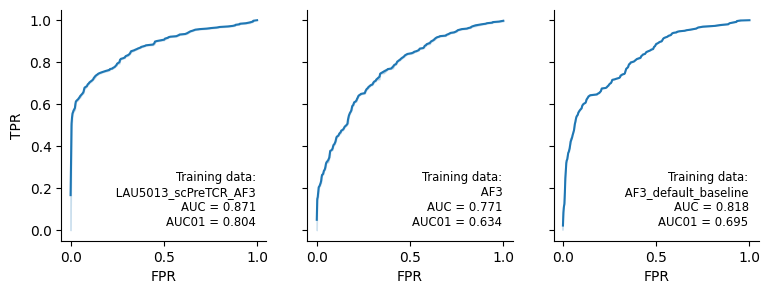

In [11]:
topdir = 'AF3_motif_validation_TEMPO'

batches = ['LAU5013_scPreTCR_AF3', 'AF3', 'AF3_default_baseline']
#

fig, axes = plt.subplots(1, 3, figsize=(9,3), sharey=True)

for cnt, batch in enumerate(batches):
    ax = axes[cnt]
    
    df = pd.read_csv(f'{topdir}/{batch}/A0201_LLWNGPMAV_pred.csv')
    df = df[df['Problem'].isna()]

    y_scores = df['score'].values
    y_true = df['label'].values


    # ROC + metrics
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc_full = roc_auc_score(y_true, y_scores)
    auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)  # standardized AUC01

    # plot
    sns.lineplot(x=fpr, y=tpr, ax=ax)
    label = f"Training data:\n {batch}\nAUC = {auc_full:.3f}\nAUC01 = {auc01:.3f}"


    ax.text(0.95, 0.05, label, transform=ax.transAxes, ha='right', va='bottom', fontsize='small')

    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    sns.despine()


# Compare dummy chain vs random pairing approach

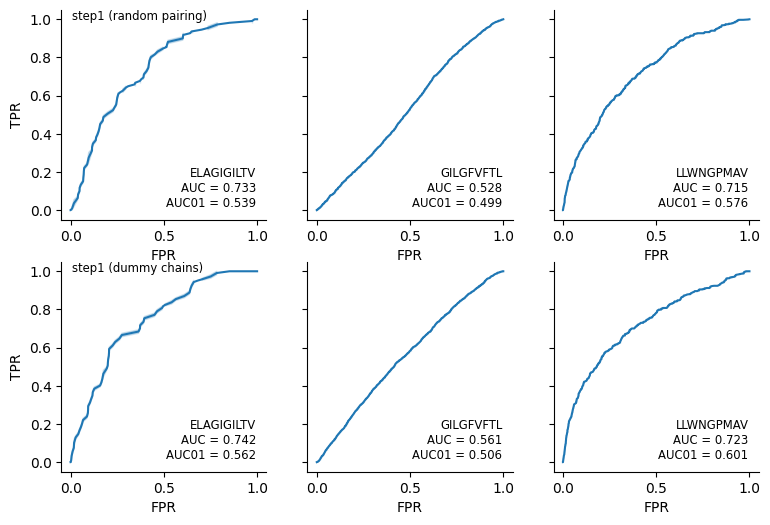

In [18]:
# prepaire csv for motif building
topdir = 'AF3_motif_validation_TEMPO'

peptides = ['ELAGIGILTV', 'GILGFVFTL', 'LLWNGPMAV']
batches = ['step1', 'dummy_chains/step1_dummy']
row_labels = ['step1 (random pairing)', 'step1 (dummy chains)']

fig, axes = plt.subplots(2, 3, figsize=(9,6), sharey=True)

for cnt1, batch in enumerate(batches):
    for cnt2, peptide in enumerate(peptides):
        ax = axes[cnt1][cnt2]

        df = pd.read_csv(f'{batch}_{peptide}/TEMPO/pred.csv')
        df = df[df['Problem'].isna()]
        
        y_scores = df['score'].values
        y_true = df['Label'].values

        # ROC + metrics
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        auc_full = roc_auc_score(y_true, y_scores)
        auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)  # standardized AUC01

        # plot
        sns.lineplot(x=fpr, y=tpr, ax=ax)
        label = f"{peptide}\nAUC = {auc_full:.3f}\nAUC01 = {auc01:.3f}"

        ax.text(0.95, 0.05, label, transform=ax.transAxes, ha='right', va='bottom', fontsize='small')

        # Add row label in upper left of first column only
        if cnt2 == 0:
            ax.text(0.05, 1.0, row_labels[cnt1], transform=ax.transAxes,
                    ha='left', va='top', fontsize='small')

        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        sns.despine()